# Este notebook analiza los hallazgos producidos por el **Miner** a partir de **results.json**.

Se estudian: 
- Severidad 
- Frecuencia de reglas
- Distribución por repositorio
- Lenguaje
- Archivos de prueba
- Hallazgos de seguridad
- concentración 
- patrones relevantes para el Visualizer.



## 1. Importaciones

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Carga de **results.json**

In [3]:
candidates = [
    Path("../../results.json"),
    Path("../results.json"),
    Path("results.json"),
]

RESULTS_FILE = next((p for p in candidates if p.exists()), None)

if RESULTS_FILE is None:
    raise FileNotFoundError(
        "No se encontró results.json. Ajusta la lista 'candidates' según la ubicación del notebook."
    )


with open(RESULTS_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)

## 3. Resumen general

In [4]:
summary = data["summary"]

print("Organización:", summary["organization"])
print("Repositorios totales:", summary["total_repositories"])
print("Repositorios analizados:", summary["analyzed_repositories"])
print("Repositorios no soportados:", summary["unsupported_repositories"])
print("Repositorios fallidos:", summary["failed_repositories"])
print("Hallazgos totales:", summary["total_findings"])

Organización: TanStack
Repositorios totales: 30
Repositorios analizados: 25
Repositorios no soportados: 1
Repositorios fallidos: 4
Hallazgos totales: 2016


### Repositorios con fallo

Los repositorios fallidos no deben interpretarse como repositorios sin hallazgos: corresponden a ejecuciones que no terminaron correctamente.


In [5]:
failed_repositories = pd.DataFrame([
    {
        "repository": repo["name"],
        "status": repo["status"],
        "error": repo.get("error")
    }
    for repo in data["repositories"]
    if repo["status"] not in ["analyzed", "unsupported"]
])

failed_repositories

,repository,status,error
0,tanstack.com,analysis_failed,Running queries.\nResolving data extensions.\n...
1,template,database_creation_failed,Initializing database at /tmp/miner-codeql-rtw...
2,virtual,database_creation_failed,Initializing database at /tmp/miner-codeql-rtw...
3,workflow,database_creation_failed,Initializing database at /tmp/miner-codeql-rtw...


## 4. Construcción del DataFrame de hallazgos

In [6]:
findings = []

for repo in data["repositories"]:
    repo_name = repo["name"]

    for finding in repo.get("findings", []):
        findings.append({
            "repository": repo_name,
            "rule_id": finding.get("rule_id"),
            "severity": finding.get("severity"),
            "message": finding.get("message"),
            "file": finding.get("file"),
            "start_line": finding.get("start_line"),
            "language": finding.get("language")
        })

df_findings = pd.DataFrame(findings)
df_findings.head()

,repository,rule_id,severity,message,file,start_line,language
0,ai,js/unused-local-variable,note,Unused variable messages.,codemods/ag-ui-compliance/__testfixtures__/use...,4,TypeScript
1,ai,js/unused-local-variable,note,Unused variable sendMessage.,codemods/ag-ui-compliance/__testfixtures__/use...,4,TypeScript
2,ai,js/unused-local-variable,note,Unused variable messages.,codemods/ag-ui-compliance/__testfixtures__/use...,4,TypeScript
3,ai,js/unused-local-variable,note,Unused variable sendMessage.,codemods/ag-ui-compliance/__testfixtures__/use...,4,TypeScript
4,ai,js/superfluous-trailing-arguments,warning,Superfluous argument passed to [function trans...,codemods/ag-ui-compliance/transform.test.ts,33,TypeScript


### Validación

In [7]:
print("Filas del DataFrame:", len(df_findings))
print("Hallazgos declarados por Miner:", data["summary"]["total_findings"])
print("Dimensiones:", df_findings.shape)

assert len(df_findings) == data["summary"]["total_findings"]

print("\nDataset cargado correctamente.")

Filas del DataFrame: 2016
Hallazgos declarados por Miner: 2016
Dimensiones: (2016, 7)

Dataset cargado correctamente.


## 5. Distribución por severidad

In [8]:
severity_counts = df_findings["severity"].value_counts()

severity_percentage = (
    df_findings["severity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

severity_summary = pd.DataFrame({
    "cantidad": severity_counts,
    "porcentaje": severity_percentage
})

severity_summary

,cantidad,porcentaje
severity,,
note,1246,61.81
warning,659,32.69
error,111,5.51


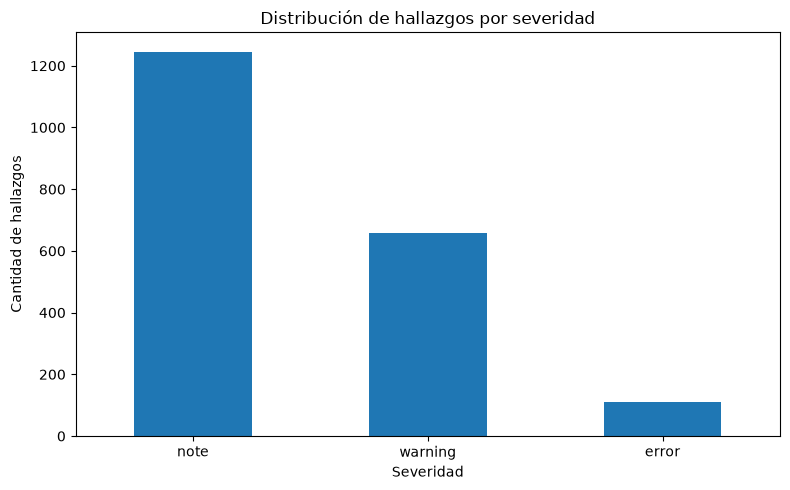

In [9]:
severity_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Distribución de hallazgos por severidad")
plt.xlabel("Severidad")
plt.ylabel("Cantidad de hallazgos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

La severidad global está dominada por **note** y **warning**. Por ello, los 2016 hallazgos no deben interpretarse como 2016 vulnerabilidades graves.

## 6. Distribución de hallazgos por repositorio

In [10]:
findings_by_repo = df_findings["repository"].value_counts()
findings_by_repo.head(10)

repository
router       660
form         263
preact       164
ai           160
container    152
charts       134
query        102
table         98
db            83
cli           68
Name: count, dtype: int64

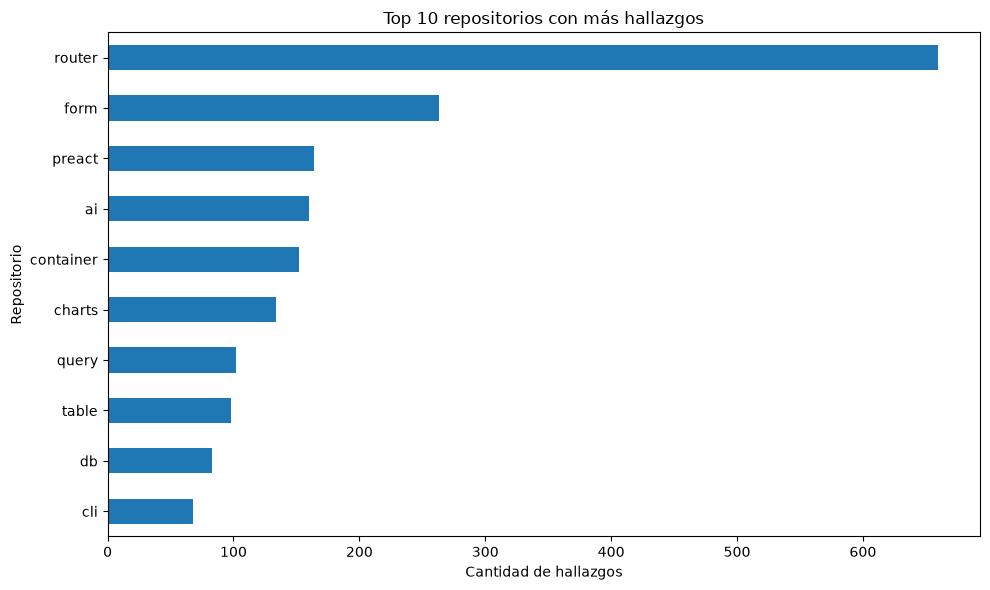

In [11]:
findings_by_repo.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 repositorios con más hallazgos")
plt.xlabel("Cantidad de hallazgos")
plt.ylabel("Repositorio")
plt.tight_layout()
plt.show()

## 7. Reglas CodeQL más frecuentes

In [12]:
top_rules = df_findings["rule_id"].value_counts()
top_rules.head(15)

rule_id
js/unused-local-variable                      1164
js/useless-assignment-to-local                 120
js/syntax-error                                 73
js/useless-expression                           54
js/trivial-conditional                          46
js/insecure-temporary-file                      43
js/stack-trace-exposure                         41
js/missing-origin-check                         39
js/unreachable-statement                        36
js/superfluous-trailing-arguments               34
js/file-system-race                             33
js/polynomial-redos                             32
js/bad-code-sanitization                        22
js/incomplete-multi-character-sanitization      21
js/log-injection                                21
Name: count, dtype: int64

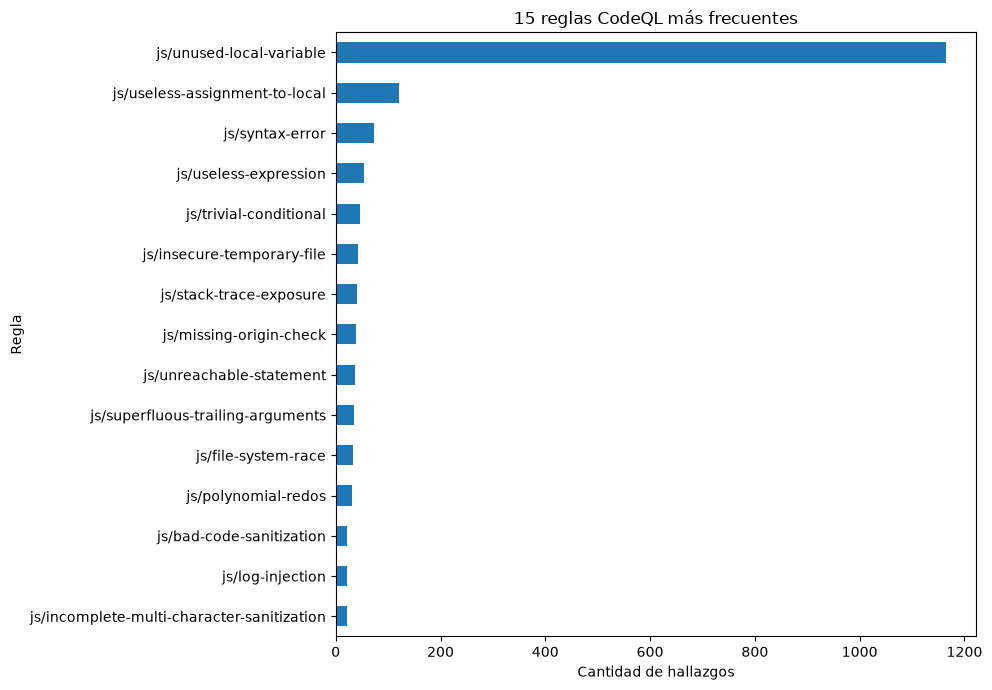

In [13]:
top_rules.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("15 reglas CodeQL más frecuentes")
plt.xlabel("Cantidad de hallazgos")
plt.ylabel("Regla")
plt.tight_layout()
plt.show()

## 8. Distribución por lenguaje

In [14]:
language_counts = df_findings["language"].value_counts()
language_counts

language
TypeScript    2015
Python           1
Name: count, dtype: int64

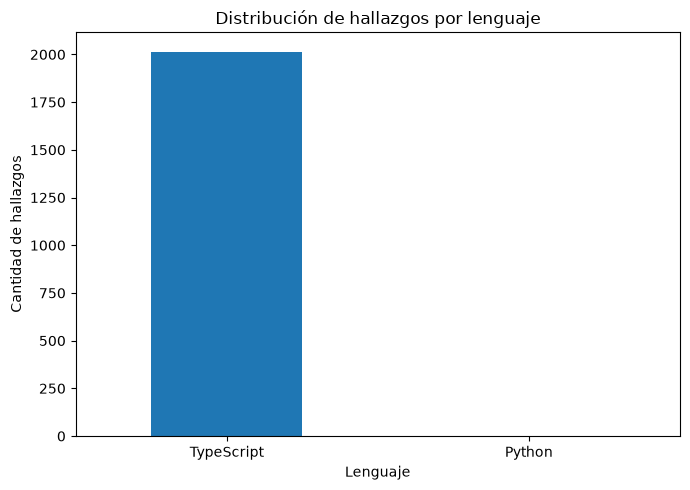

In [15]:
language_counts.plot(kind="bar", figsize=(7, 5))

plt.title("Distribución de hallazgos por lenguaje")
plt.xlabel("Lenguaje")
plt.ylabel("Cantidad de hallazgos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

El análisis se concentra prácticamente por completo en **TypeScript**: 2015 hallazgos corresponden a TypeScript y 1 a Python.

## 9. Identificación de archivos de prueba

In [16]:
df_findings["is_test"] = df_findings["file"].str.contains(
    r"(?:^|/)(?:__tests__|__testfixtures__|test|tests|spec|specs|testing)(?:/|$)|(?:\.test\.|\.spec\.)",
    case=False,
    regex=True,
    na=False
)

test_counts = df_findings["is_test"].value_counts()

test_percentages = (
    df_findings["is_test"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

pd.DataFrame({
    "cantidad": test_counts,
    "porcentaje": test_percentages
}).rename(index={True: "Pruebas", False: "Otros archivos"})

,cantidad,porcentaje
is_test,,
Pruebas,1322,65.58
Otros archivos,694,34.42


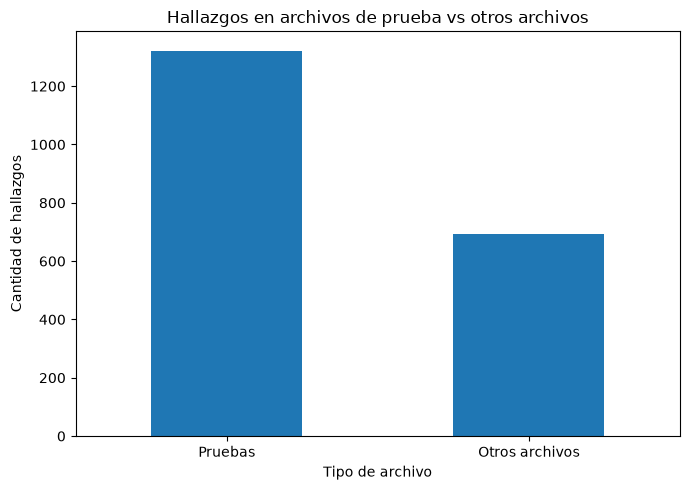

In [17]:
test_distribution = (
    df_findings["is_test"]
    .map({True: "Pruebas", False: "Otros archivos"})
    .value_counts()
)

test_distribution.plot(kind="bar", figsize=(7, 5))

plt.title("Hallazgos en archivos de prueba vs otros archivos")
plt.xlabel("Tipo de archivo")
plt.ylabel("Cantidad de hallazgos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

De los 2016 hallazgos, **1322 (65.58 %)** se encuentran en archivos asociados a pruebas y **694 (34.42 %)** en otros archivos. Esto obliga a interpretar con cautela los conteos globales.

## 10. Hallazgos fuera de archivos de prueba

In [18]:
df_non_test = df_findings[
    df_findings["is_test"] == False
].copy()

non_test_by_repo = df_non_test["repository"].value_counts()
non_test_by_repo.head(10)

repository
router       130
container    111
table         91
ai            85
cli           62
charts        42
db            31
bling         29
form          19
redact        15
Name: count, dtype: int64

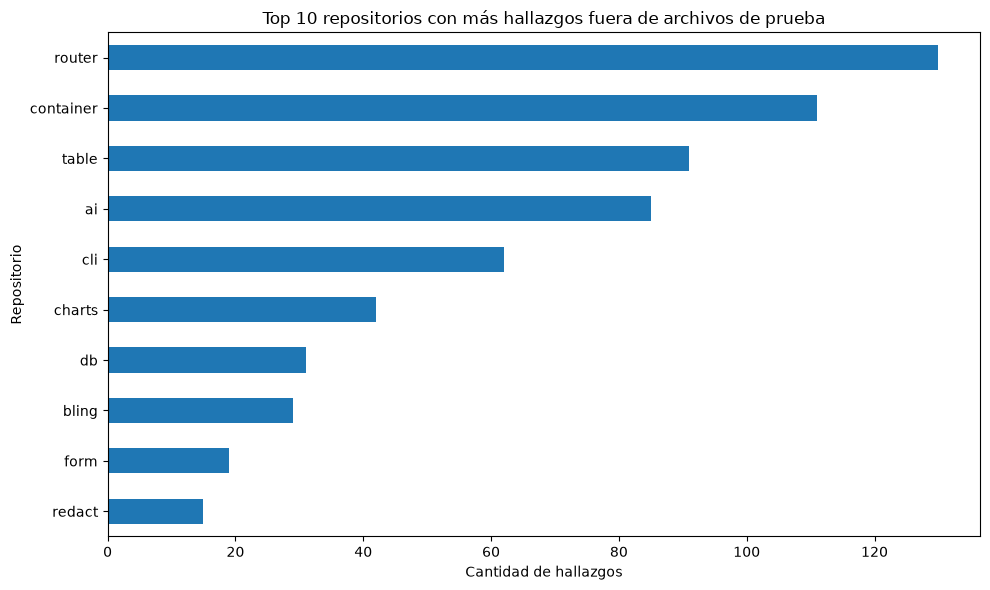

In [19]:
non_test_by_repo.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 repositorios con más hallazgos fuera de archivos de prueba")
plt.xlabel("Cantidad de hallazgos")
plt.ylabel("Repositorio")
plt.tight_layout()
plt.show()

## 11. Clasificación operacional: seguridad vs calidad

La siguiente clasificación separa reglas directamente relacionadas con seguridad de reglas principalmente asociadas a calidad o corrección. Es una decisión metodológica del Analyzer y no reemplaza una validación manual de cada hallazgo.

In [20]:
security_rules = [
    "js/bad-code-sanitization",
    "js/biased-cryptographic-random",
    "js/client-side-request-forgery",
    "js/client-side-unvalidated-url-redirection",
    "js/cors-misconfiguration-for-credentials",
    "js/double-escaping",
    "js/file-access-to-http",
    "js/file-system-race",
    "js/functionality-from-untrusted-source",
    "js/html-constructed-from-input",
    "js/http-to-file-access",
    "js/incomplete-multi-character-sanitization",
    "js/incomplete-sanitization",
    "js/incomplete-url-scheme-check",
    "js/incomplete-url-substring-sanitization",
    "js/indirect-command-line-injection",
    "js/insecure-randomness",
    "js/insecure-temporary-file",
    "js/log-injection",
    "js/missing-origin-check",
    "js/missing-rate-limiting",
    "js/polynomial-redos",
    "js/prototype-polluting-assignment",
    "js/redos",
    "js/reflected-xss",
    "js/regex-injection",
    "js/regex/missing-regexp-anchor",
    "js/remote-property-injection",
    "js/resource-exhaustion",
    "js/server-side-unvalidated-url-redirection",
    "js/shell-command-constructed-from-input",
    "js/shell-command-injection-from-environment",
    "js/stack-trace-exposure",
    "js/tainted-format-string",
    "js/unvalidated-dynamic-method-call",
    "js/xss-through-dom",
    "js/xss-through-exception"
]

df_findings["category"] = np.where(
    df_findings["rule_id"].isin(security_rules),
    "security",
    "code_quality"
)

category_counts = df_findings["category"].value_counts()

category_percentages = (
    df_findings["category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

pd.DataFrame({
    "cantidad": category_counts,
    "porcentaje": category_percentages
})

,cantidad,porcentaje
category,,
code_quality,1649,81.8
security,367,18.2


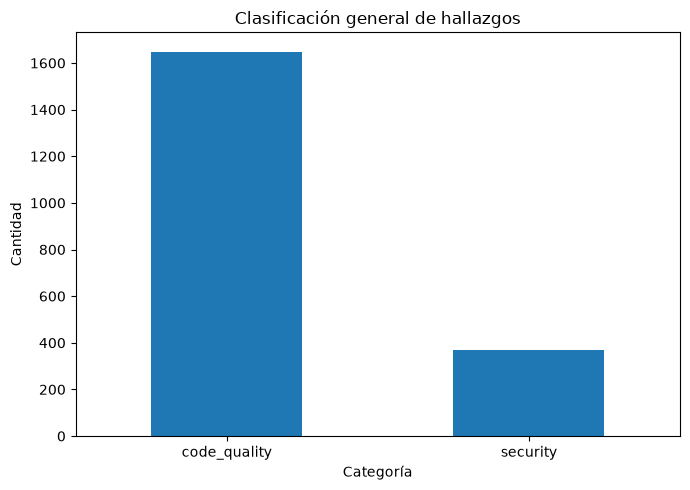

In [21]:
category_counts.plot(kind="bar", figsize=(7, 5))

plt.title("Clasificación general de hallazgos")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

La clasificación resultante contiene **1649 hallazgos de calidad/corrección (81.8 %)** y **367 hallazgos relacionados con seguridad (18.2 %)**.

## 12. Subconjunto de hallazgos de seguridad

In [22]:
df_security = df_findings[
    df_findings["category"] == "security"
].copy()

print("Hallazgos de seguridad:", len(df_security))
assert len(df_security) == 367

df_security.head()

Hallazgos de seguridad: 367


,repository,rule_id,severity,message,file,start_line,language,is_test,category
9,ai,js/stack-trace-exposure,warning,This information exposed to the user depends o...,examples/ts-code-mode-web/src/routes/_reportin...,241,TypeScript,False,security
10,ai,js/server-side-unvalidated-url-redirection,warning,Untrusted URL redirection depends on a [user-p...,examples/ts-react-chat/scripts/serve-chatgpt-c...,16,TypeScript,False,security
16,ai,js/xss-through-dom,warning,[DOM text](1) is reinterpreted as HTML without...,examples/ts-react-media/src/components/SeedIma...,52,TypeScript,False,security
24,ai,js/redos,error,This part of the regular expression may cause ...,packages/ai-byteplus/src/adapters/transcriptio...,413,TypeScript,False,security
25,ai,js/polynomial-redos,warning,This [regular expression](1) that depends on [...,packages/ai-byteplus/src/utils/client.ts,132,TypeScript,False,security


### Severidad de los hallazgos de seguridad

In [23]:
security_severity = df_security["severity"].value_counts()

security_severity_percentage = (
    df_security["severity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

pd.DataFrame({
    "cantidad": security_severity,
    "porcentaje": security_severity_percentage
})

,cantidad,porcentaje
severity,,
warning,294,80.11
error,73,19.89


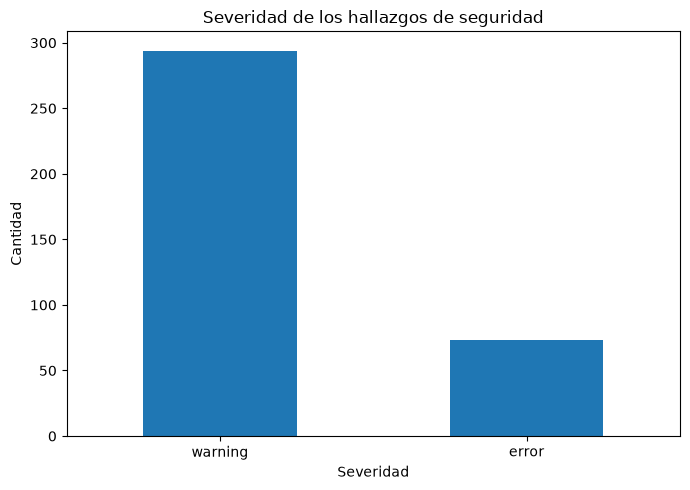

In [24]:
security_severity.plot(kind="bar", figsize=(7, 5))

plt.title("Severidad de los hallazgos de seguridad")
plt.xlabel("Severidad")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Dentro de los 367 hallazgos de seguridad, **294 son `warning` (80.11 %)** y **73 son `error` (19.89 %)**.

## 13. Tipos de hallazgos de seguridad

In [25]:
security_rule_counts = df_security["rule_id"].value_counts()
security_rule_counts.head(15)

rule_id
js/insecure-temporary-file                    43
js/stack-trace-exposure                       41
js/missing-origin-check                       39
js/file-system-race                           33
js/polynomial-redos                           32
js/bad-code-sanitization                      22
js/incomplete-multi-character-sanitization    21
js/log-injection                              21
js/http-to-file-access                        14
js/file-access-to-http                         9
js/shell-command-constructed-from-input        9
js/missing-rate-limiting                       9
js/incomplete-sanitization                     7
js/html-constructed-from-input                 7
js/remote-property-injection                   6
Name: count, dtype: int64

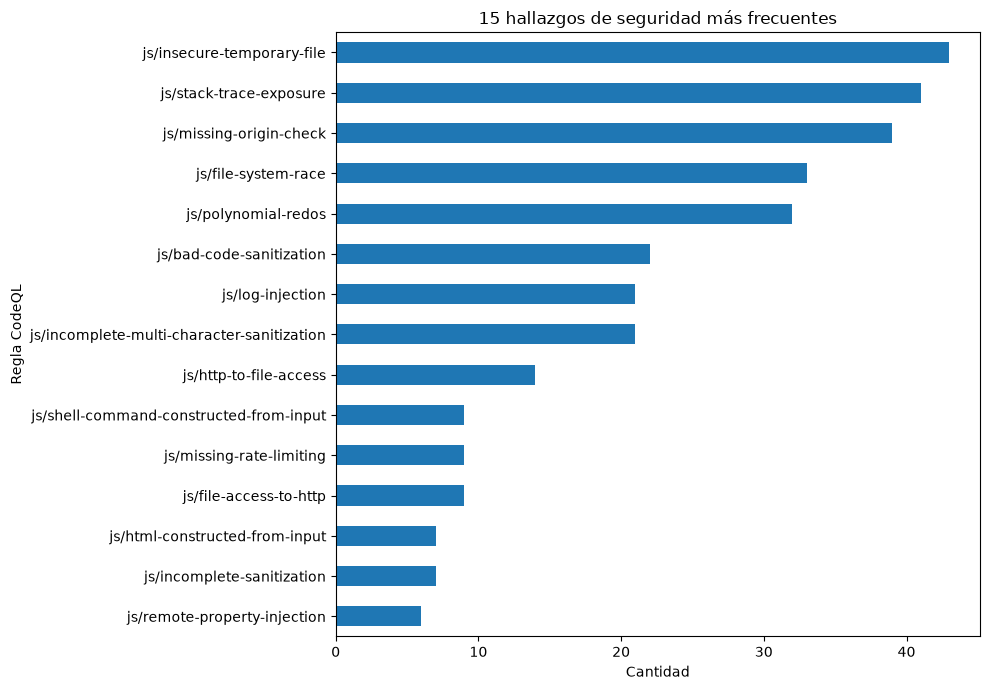

In [26]:
security_rule_counts.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("15 hallazgos de seguridad más frecuentes")
plt.xlabel("Cantidad")
plt.ylabel("Regla CodeQL")
plt.tight_layout()
plt.show()

Las reglas de seguridad más frecuentes son 
- js/insecure-temporary-file
- js/stack-trace-exposure
- js/missing-origin-check
- js/file-system-race
- js/polynomial-redos`.

## 14. Hallazgos de seguridad por repositorio

In [27]:
security_by_repo = df_security["repository"].value_counts()
security_by_repo.head(15)

repository
ai           87
container    80
router       61
db           24
intent       20
table        18
charts       13
config        9
markdown      9
redact        9
cli           8
alt-cli       7
devtools      7
bling         5
query         5
Name: count, dtype: int64

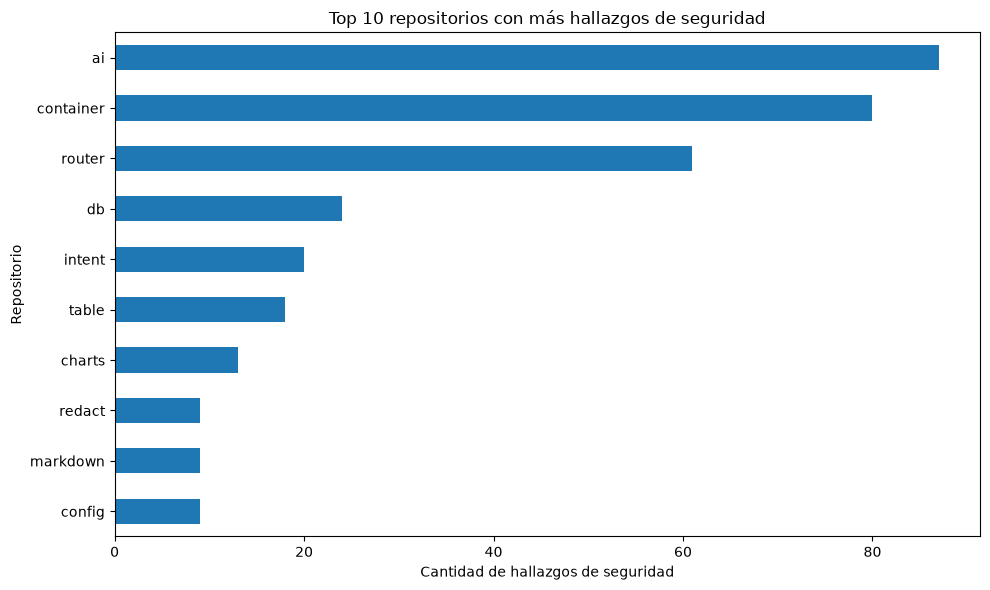

In [28]:
security_by_repo.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 repositorios con más hallazgos de seguridad")
plt.xlabel("Cantidad de hallazgos de seguridad")
plt.ylabel("Repositorio")
plt.tight_layout()
plt.show()

En cantidad absoluta, **ai**, **container** y **router** concentran la mayor cantidad de hallazgos clasificados como seguridad.

## 15. Seguridad en pruebas vs otros archivos

In [29]:
security_test_counts = df_security["is_test"].value_counts()

security_test_percentages = (
    df_security["is_test"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

pd.DataFrame({
    "cantidad": security_test_counts,
    "porcentaje": security_test_percentages
}).rename(index={True: "Pruebas", False: "Otros archivos"})

,cantidad,porcentaje
is_test,,
Otros archivos,262,71.39
Pruebas,105,28.61


A diferencia del total general, **262 hallazgos de seguridad (71.39 %)** se encuentran fuera de archivos de prueba y **105 (28.61 %)** dentro de pruebas.

## 16. Seguridad fuera de archivos de prueba

In [30]:
security_non_test = df_security[
    df_security["is_test"] == False
].copy()

security_non_test_by_repo = security_non_test["repository"].value_counts()
security_non_test_by_repo.head(10)

repository
container    57
router       51
ai           35
db           23
table        16
charts       13
config        9
markdown      9
redact        9
alt-cli       7
Name: count, dtype: int64

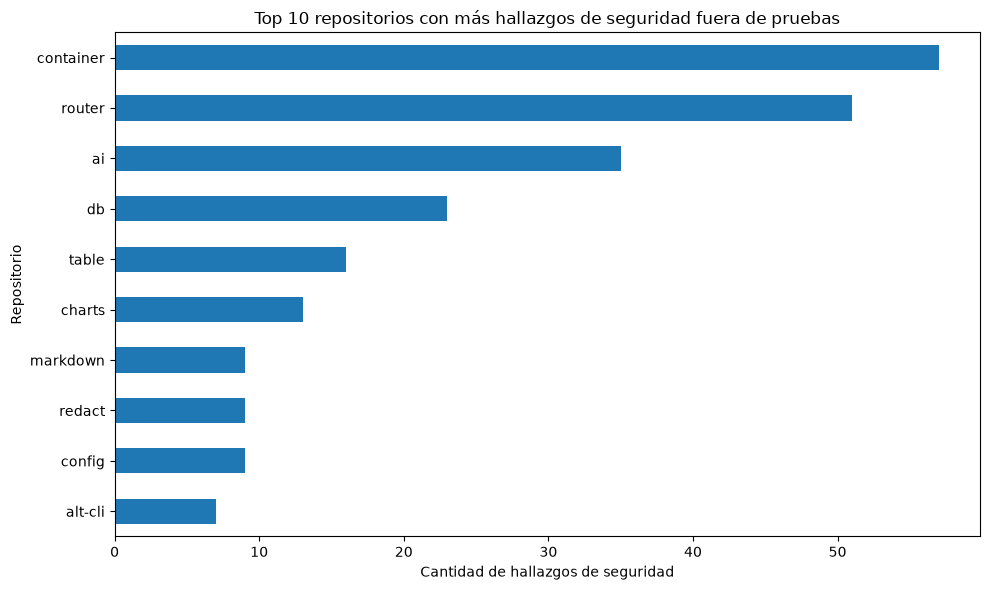

In [31]:
security_non_test_by_repo.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 repositorios con más hallazgos de seguridad fuera de pruebas")
plt.xlabel("Cantidad de hallazgos de seguridad")
plt.ylabel("Repositorio")
plt.tight_layout()
plt.show()

Al excluir archivos de prueba, `container`, `router` y `ai` son los repositorios con más hallazgos de seguridad.

## 17. Tabla resumen por repositorio

In [32]:
repo_security_summary = df_findings.groupby("repository").agg(
    total_findings=("rule_id", "count"),
    unique_rules=("rule_id", "nunique"),
    files_affected=("file", "nunique"),
    security_findings=("category", lambda x: (x == "security").sum()),
    test_findings=("is_test", "sum")
)

repo_security_summary["security_percentage"] = (
    repo_security_summary["security_findings"]
    / repo_security_summary["total_findings"]
    * 100
).round(2)

repo_security_summary["test_percentage"] = (
    repo_security_summary["test_findings"]
    / repo_security_summary["total_findings"]
    * 100
).round(2)

repo_security_summary.sort_values(
    "security_findings",
    ascending=False
).head(15)

,total_findings,unique_rules,files_affected,security_findings,test_findings,security_percentage,test_percentage
repository,,,,,,,
ai,160,23,100,87,75,54.37,46.88
container,152,26,103,80,41,52.63,26.97
router,660,29,316,61,530,9.24,80.30
db,83,20,33,24,52,28.92,62.65
intent,20,5,9,20,13,100.00,65.00
table,98,15,45,18,7,18.37,7.14
charts,134,9,54,13,92,9.70,68.66
markdown,10,5,6,9,0,90.00,0.00
redact,18,9,14,9,3,50.00,16.67


## 18. Concentración de hallazgos de seguridad

In [33]:
security_concentration = pd.DataFrame({
    "security_findings": security_by_repo
})

security_concentration["percentage"] = (
    security_concentration["security_findings"]
    / security_concentration["security_findings"].sum()
    * 100
).round(2)

security_concentration["cumulative_percentage"] = (
    security_concentration["percentage"]
    .cumsum()
    .round(2)
)

security_concentration.head(10)

,security_findings,percentage,cumulative_percentage
repository,,,
ai,87,23.71,23.71
container,80,21.80,45.51
router,61,16.62,62.13
db,24,6.54,68.67
intent,20,5.45,74.12
table,18,4.90,79.02
charts,13,3.54,82.56
config,9,2.45,85.01
markdown,9,2.45,87.46


In [34]:
top3_share = security_by_repo.head(3).sum() / len(df_security) * 100
top5_share = security_by_repo.head(5).sum() / len(df_security) * 100

print(f"Top 3: {top3_share:.2f}%")
print(f"Top 5: {top5_share:.2f}%")

Top 3: 62.13%
Top 5: 74.11%


Los tres repositorios con más hallazgos de seguridad (**ai**, **container** y **router**) concentran aproximadamente **62.13 %** del total de seguridad. Los cinco primeros concentran aproximadamente **74.11 %**. Esto evidencia una concentración importante y no una distribución uniforme.

## 19. Conclusiones

El análisis de TanStack identificó **2016 hallazgos** mediante CodeQL.

Principales observaciones:

- La evidencia está concentrada casi completamente en **TypeScript**.
- La severidad global está dominada por **note** y **warning**.
- **65.58 %** de los hallazgos generales aparece en archivos asociados a pruebas.
- Bajo la clasificación operacional utilizada, **367 hallazgos (18.2 %)** se consideran relacionados con seguridad.
- Dentro de seguridad predominan los **warning** (**80.11 %**).
- Aunque la mayoría de los hallazgos generales está en tests, **71.39 % de los hallazgos de seguridad está fuera de archivos de prueba**.
- **ai**, **container** y **router** concentran aproximadamente **62.13 %** de los hallazgos de seguridad.
- Al excluir archivos de prueba, **container**, **router** y **ai** siguen destacando.



## 20. Exportación de resultados para el Visualizer

In [35]:
OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df_findings.to_csv(OUTPUT_DIR / "findings.csv", index=False)
df_security.to_csv(OUTPUT_DIR / "security_findings.csv", index=False)
repo_security_summary.reset_index().to_csv(
    OUTPUT_DIR / "repository_summary.csv",
    index=False
)
security_concentration.reset_index().to_csv(
    OUTPUT_DIR / "security_concentration.csv",
    index=False
)

repo_security_summary.reset_index().to_json(
    OUTPUT_DIR / "repository_summary.json",
    orient="records",
    indent=2
)

security_concentration.reset_index().to_json(
    OUTPUT_DIR / "security_concentration.json",
    orient="records",
    indent=2
)

print("Resultados exportados en:", OUTPUT_DIR.resolve())

Resultados exportados en: /home/franshe/Documentos/ciberseguridad/rm-miner/rm-miner/output
